## 1. Imports

In [3]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.preprocessing import StandardScaler
import joblib

## 2. Data Split and Normalization

In [5]:
df = pd.read_csv('data/clean_dataset.csv')

In [6]:
x = df.drop(columns = ['stress_level'])
y = df['stress_level']

x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size = 0.3, random_state = 42
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size = 0.5, random_state = 42
)

In [13]:
FEATURE_COLS = x_train.columns.tolist()
joblib.dump(FEATURE_COLS, 'models/feature_cols.pkl')

['models/feature_cols.pkl']

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(x_train)
X_val = scaler.transform(x_val)
X_test = scaler.transform(x_test)

In [10]:
joblib.dump(scaler, 'models/scaler.pkl')

['models/scaler.pkl']

## 3. Baseline model

In [7]:
model_baseline = Sequential([
    Dense(64, activation = 'relu', input_shape = (x_train.shape[1],)),
    Dense(32, activation = 'relu'),
    Dense(16, activation = 'relu'),
    Dense(1)
])

c:\Users\andre\stress-prediction\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model_baseline.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

In [9]:
history = model_baseline.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 100,
    batch_size = 64
)

Epoch 1/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 34.5222 - mae: 5.1293 - val_loss: 8.5208 - val_mae: 2.5566
Epoch 2/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.6453 - mae: 2.4146 - val_loss: 7.3980 - val_mae: 2.3627
Epoch 3/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.5821 - mae: 2.4012 - val_loss: 7.3976 - val_mae: 2.3622
Epoch 4/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.5860 - mae: 2.4020 - val_loss: 7.3972 - val_mae: 2.3617
Epoch 5/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.5874 - mae: 2.4025 - val_loss: 7.3978 - val_mae: 2.3624
Epoch 6/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.5849 - mae: 2.4025 - val_loss: 7.3966 - val_mae: 2.3608
Epoch 7/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.5851 - mae: 2.4020 - val_loss: 7.3961 - val_mae: 2.3583
Epoch 8/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7.5840 - mae: 2.4009 - val_loss: 7.3962 - val_mae: 2.3579
Epoch 9/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms

In [25]:
def visualizar_graficas(history):
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    eps = range(1, len(mae) + 1)

    # MAE
    plt.plot(eps, mae, 'r', label='train MAE')
    plt.plot(eps, val_mae, 'b', label='validation MAE')
    plt.title('Train MAE vs. Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()

    plt.figure()

    # Loss (MSE)
    plt.plot(eps, loss, 'r', label='training loss (MSE)')
    plt.plot(eps, val_loss, 'b', label='validation loss (MSE)')
    plt.title('Train Loss vs. Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE')
    plt.legend()

    plt.show()

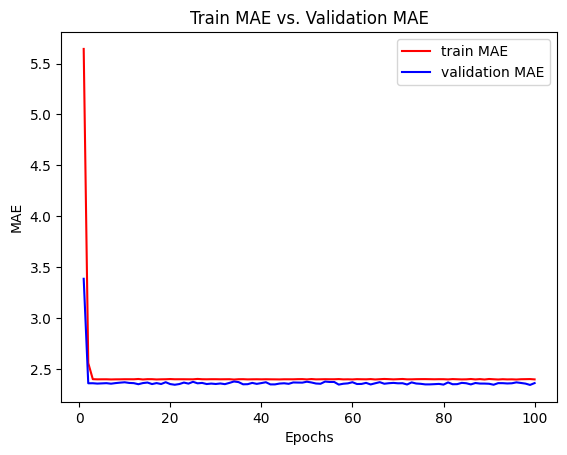

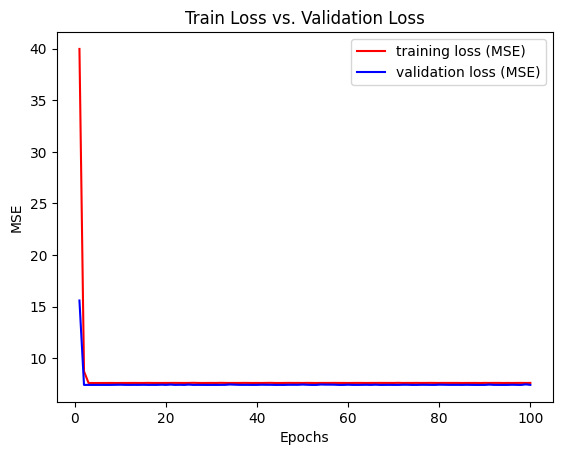

In [26]:
visualizar_graficas(history)

In [ ]:
model_baseline.save('models/model_baseline.keras')